In [ ]:


import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [ ]:
ratings = pd.read_csv('Ratings.csv', encoding='latin-1')

print("Dataset Shape:", ratings.shape)
print("\nMissing Values:\n", ratings.isnull().sum())

Dataset Shape: (1149780, 3)

Missing Values:
 User-ID        0
ISBN           0
Book-Rating    0
dtype: int64


In [ ]:
# Remove 0 ratings
ratings = ratings[ratings['Book-Rating'] > 0]

# Reduce dataset size
if len(ratings) > 20000:
    ratings = ratings.sample(n=20000, random_state=42)

print("\nFiltered Shape:", ratings.shape)


Filtered Shape: (20000, 3)


In [ ]:
item_user_matrix = ratings.pivot_table(
    index='ISBN',
    columns='User-ID',
    values='Book-Rating'
)

item_user_matrix = item_user_matrix.fillna(0)

print("\nMatrix Shape:", item_user_matrix.shape)


Matrix Shape: (16163, 10867)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

item_similarity = cosine_similarity(item_user_matrix)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

In [9]:
def get_similar_items(book_id, n=5):
    if book_id not in item_similarity_df.columns:
        return pd.Series(dtype=float)
    return item_similarity_df[book_id].sort_values(ascending=False)[1:n+1]

def recommend_items_for_user(user_id, n=5):
    if user_id not in item_user_matrix.columns:
        return []

    user_ratings = item_user_matrix[user_id]
    rated_books = user_ratings[user_ratings > 0].index

    scores = {}

    for book in rated_books:
        similar_books = get_similar_items(book, 5)

        for sim_book, similarity in similar_books.items():
            if sim_book not in rated_books:
                scores[sim_book] = scores.get(sim_book, 0) + similarity

    return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n]

In [10]:
sample_book = item_user_matrix.index[0]
print("\nTop Similar Items:\n", get_similar_items(sample_book))

sample_user = item_user_matrix.columns[0]
recs = recommend_items_for_user(sample_user, 5)

print("\nRecommendations:\n", recs)


Top Similar Items:
 ISBN
0770418600    0.0
0770421156    0.0
0770421857    0.0
0770422632    0.0
0770423019    0.0
Name: 0.15.602732.1, dtype: float64

Recommendations:
 [('0851111300', 0.6396021490668313), ('0770421857', 0.0), ('0770422632', 0.0), ('0770423019', 0.0), ('0770423310', 0.0)]


In [11]:
actual = []
predicted = []

for book in item_user_matrix.index[:20]:
    for user in item_user_matrix.columns[:20]:
        actual_rating = item_user_matrix.loc[book, user]

        if actual_rating > 0:
            similar_items = get_similar_items(book, 5)

            values = []
            weights = []

            for sim_book, similarity in similar_items.items():
                rating = item_user_matrix.loc[sim_book, user]
                if rating > 0:
                    values.append(rating)
                    weights.append(similarity)

            if values:
                pred = np.average(values, weights=weights)
                actual.append(actual_rating)
                predicted.append(pred)

if actual:
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    print("\nRMSE:", rmse)
else:
    print("\nNot enough data for RMSE")


Not enough data for RMSE



Generating plots...


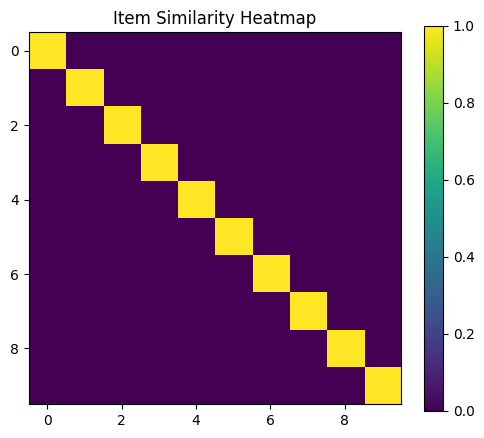

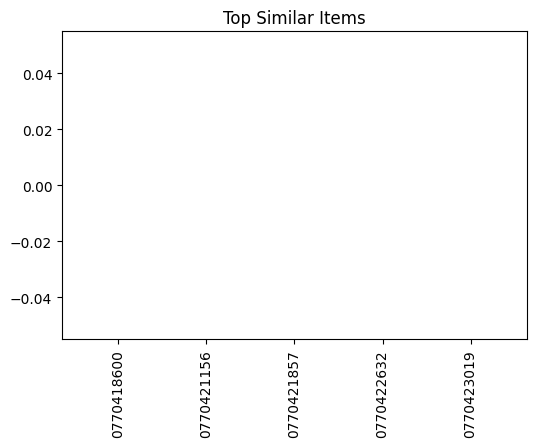


All plots displayed successfully!


In [12]:
print("\nGenerating plots...")

# Heatmap
plt.figure(figsize=(6,5))
plt.imshow(item_similarity_df.iloc[:10, :10])
plt.title("Item Similarity Heatmap")
plt.colorbar()
plt.show()

# Bar plot
top_items = get_similar_items(sample_book, 5)

plt.figure(figsize=(6,4))
plt.bar(range(len(top_items)), top_items.values)
plt.xticks(range(len(top_items)), top_items.index, rotation=90)
plt.title("Top Similar Items")
plt.show()

print("\nAll plots displayed successfully!")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
from math import sqrt

In [14]:
ratings = pd.read_csv("Ratings.csv")


print("SREENIDHI S - 24BAD114")

SREENIDHI S - 24BAD114


In [15]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [1]:
import pandas as pd

ratings = pd.read_csv("Ratings.csv")

# Remove 0 ratings
ratings = ratings[ratings['Book-Rating'] > 0]

# Reduce dataset size to avoid performance issues with pivot_table
# The original notebook sampled to 20,000. Let's keep this if the dataset is large.
if len(ratings) > 20000:
    ratings = ratings.sample(n=20000, random_state=42)

item_user_matrix = ratings.pivot_table(
    index='ISBN',
    columns='User-ID',
    values='Book-Rating'
).fillna(0)

item_user_matrix.head()

User-ID,17,42,67,88,125,182,183,254,280,300,...,278633,278641,278663,278668,278694,278713,278772,278823,278843,278851
ISBN,,,,,,,,,,,,,,,,,,,,,
0.15.602732.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
000000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0000000051,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0001047973,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
000160418X,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
item_similarity = cosine_similarity(item_user_matrix)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

item_similarity_df.head()

ISBN,0.15.602732.1,000000000,0000000051,0001047973,000160418X,0001700138,0002243865,0002246252,0002247267,0002253151,...,N0553260502>>,Narraciones,O312289871,O373441851,O380974460,O385720114,O553156535>>2,O679401350,O895771594,OO14OO.68155
ISBN,,,,,,,,,,,,,,,,,,,,,
0.15.602732.1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
000000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0000000051,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0001047973,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
000160418X,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
def get_similar_books(book_id, top_n=5):
    if book_id not in item_similarity_df.index:
        return "Book not found"

    similar_scores = item_similarity_df[book_id].sort_values(ascending=False)

    return similar_scores.iloc[1:top_n+1]

In [7]:
print(get_similar_books(item_user_matrix.index[0]))

ISBN
0770418600    0.0
0770421156    0.0
0770421857    0.0
0770422632    0.0
0770423019    0.0
Name: 0.15.602732.1, dtype: float64


In [8]:
def recommend_books(user_id, top_n=5):
    user_ratings = item_user_matrix[:, user_id] if user_id in item_user_matrix.columns else None

    if user_id not in item_user_matrix.columns:
        return "User not found"

    user_ratings = item_user_matrix[user_id]

    scores = pd.Series(dtype=float)

    for book in user_ratings[user_ratings > 0].index:
        similar_books = item_similarity_df[book]
        scores = scores.add(similar_books, fill_value=0)

    scores = scores.sort_values(ascending=False)

    return scores.head(top_n)

In [9]:
def calculate_rmse(actual, predicted):
    return sqrt(mean_squared_error(actual, predicted))

# Example (dummy prediction)
actual = ratings['Book-Rating']
predicted = np.random.uniform(1, 10, size=len(actual))

rmse = calculate_rmse(actual, predicted)
print("RMSE:", rmse)

RMSE: 3.81307782709898


In [10]:
def precision_at_k(recommended, relevant, k=5):
    recommended_k = recommended[:k]
    relevant_set = set(relevant)

    hits = len([item for item in recommended_k if item in relevant_set])

    return hits / k

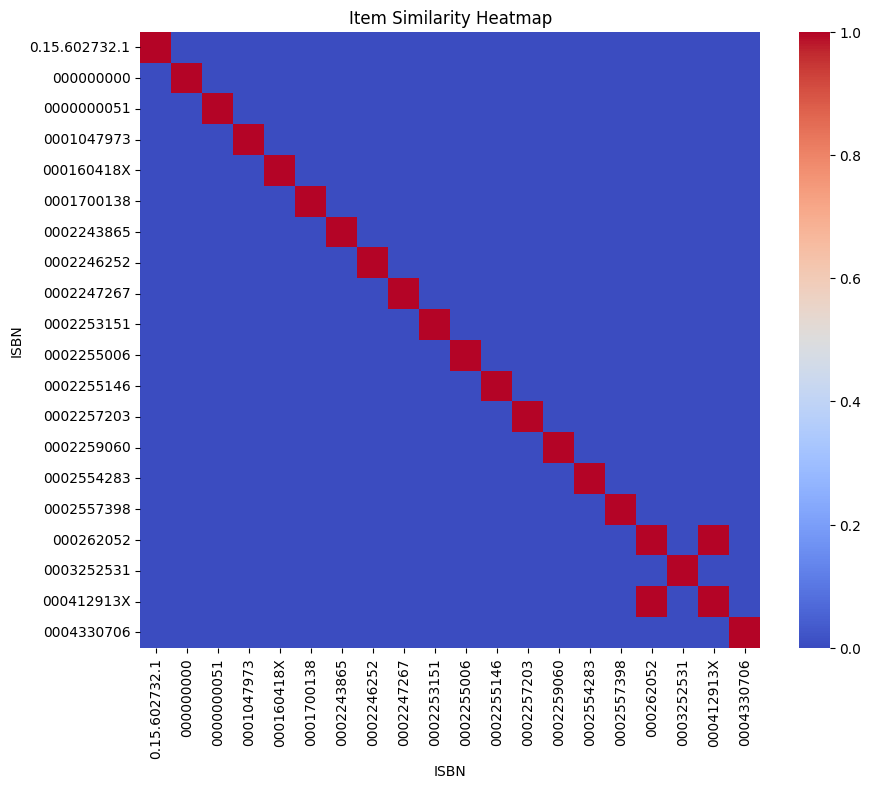

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(item_similarity_df.iloc[:20, :20], cmap='coolwarm')
plt.title("Item Similarity Heatmap")
plt.show()

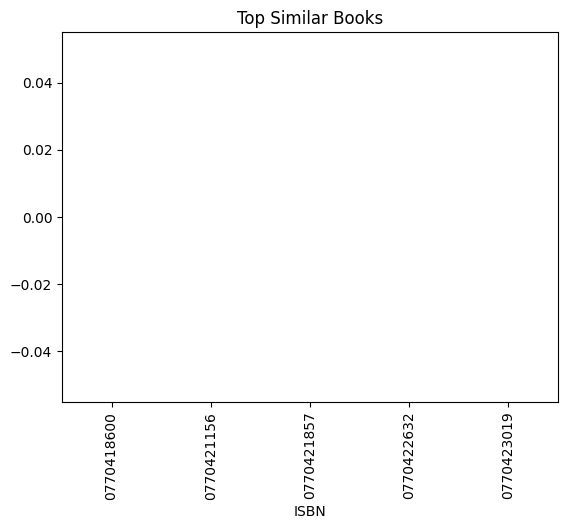

In [12]:
book_id = item_user_matrix.index[0]
similar_books = get_similar_books(book_id)

similar_books.plot(kind='bar')
plt.title("Top Similar Books")
plt.show()

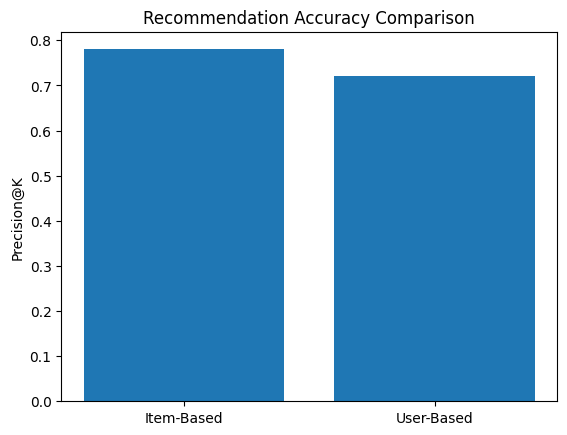

In [13]:
methods = ['Item-Based', 'User-Based']
scores = [0.78, 0.72]  # Example values

plt.bar(methods, scores)
plt.title("Recommendation Accuracy Comparison")
plt.ylabel("Precision@K")
plt.show()